In [231]:
import random
import string
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt


def get_bit_data_channel() -> tuple[np.uint8, np.uint8]:
    chars = string.ascii_uppercase
    l = len(chars)

    if not hasattr(get_bit_data_channel, 'i'):
        get_bit_data_channel.i = 0

    i: int = get_bit_data_channel.i
    c = ord(chars[i % l])
    get_bit_data_channel.i = i + 1
    return (np.uint8((c >> 3) & 1), np.uint8((c >> 4) & 1))


def get_bit_rand_channel() -> tuple[np.uint8, np.uint8]:
    return (np.uint8(random.random() >= 0.5), np.uint8(random.random() >= 0.5))


def run_channel_sim(s: int, bit_generator: Callable) -> tuple[float, float, float, float]:
    match_list_00 = np.zeros((s, 1), dtype=np.uint8)
    match_list_01 = np.zeros((s, 1), dtype=np.uint8)
    match_list_10 = np.zeros((s, 1), dtype=np.uint8)
    match_list_11 = np.zeros((s, 1), dtype=np.uint8)

    for i in range(s):
        seq = bit_generator()
        match_list_00[i] = np.uint8(seq == (0, 0))
        match_list_01[i] = np.uint8(seq == (0, 1))
        match_list_10[i] = np.uint8(seq == (1, 0))
        match_list_11[i] = np.uint8(seq == (1, 1))

    p00 = float(match_list_00.sum() / s)
    p01 = float(match_list_01.sum() / s)
    p10 = float(match_list_10.sum() / s)
    p11 = float(match_list_11.sum() / s)

    return (p00, p01, p10, p11)


def plot_p_dist(p_dist: tuple[float, float, float, float]):
    plt.bar(['00', '01', '10', '11'], p_dist)

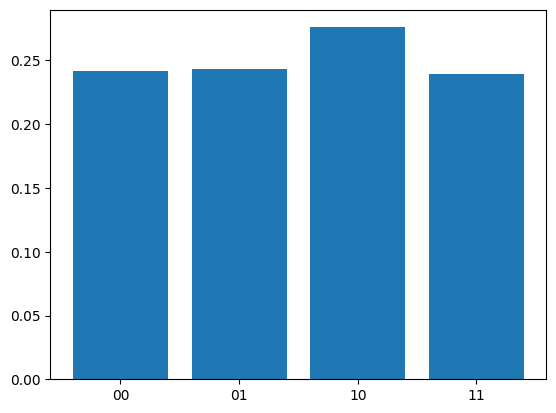

In [232]:
# rand channel
rand_ch = run_channel_sim(1000, get_bit_rand_channel)
plot_p_dist(rand_ch)

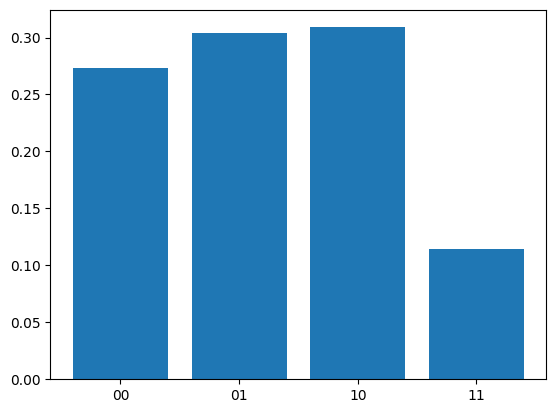

In [233]:
# data channel
data_ch = run_channel_sim(1000, get_bit_data_channel)
plot_p_dist(data_ch)